# Build one local datacube for a small ROI

This notebook shows how to combine several datasets into a single cube in a simple way, based on nearest neighbours interpolation . It is similar to how the large 100m Antarctica cubes were built:
1. Creating a regular target grid
2. Transforming all the data to zarr raster datsets 
3. Interpolation to the target grid the using nearest neighbour method

The example uses an 80 km by 80 km Amundsen Sea region at 200 m spacing, for a specific date, which is small enough to run quickly.  If you want to run it one a larger area, or time horizon youll have to update the code.

In [ ]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
from dask.diagnostics import ProgressBar
from pyproj import CRS, Transformer
from rasterio import features
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from rasterio.warp import reproject, transform_bounds
from scipy.spatial import cKDTree
from shapely.geometry import box

pd.set_option("display.max_colwidth", 120)

TARGET_CRS = "EPSG:3031"
AOI_CENTER_XY_M = (-1_600_000.0, -350_000.0)
AOI_WIDTH_M = 80_000
TARGET_RESOLUTION_M = 200
VELOCITY_TIME_TARGET = "2019-01-01"
ICE_TEMPERATURE_DEPTH_M = 1_000

OUTPUT_DIR = Path("../downloaded_data/")
FINAL_CUBE = OUTPUT_DIR / "amundsen_200m_demo_cube.zarr"

S3_OPTIONS = {
    "anon": True,
    "client_kwargs": {
        "endpoint_url": "https://s3.waw4-1.cloudferro.com",
        "region_name": "eu-west-2",
    },
}


In [2]:
SOURCES = {
    "bedmachine_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.zarr/",
    "sec_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/surface_elevation/ESACCI-AIS-L3C-SEC-MULTIMISSION-5KM-5YEAR-MEANS-1991-2021-fv1.zarr/",
    "ice_velocity_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/",
    "ice_temperature_zarr": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_sheet_temperature/SM_TEST_MIR_ITUDP4_20130101T000000_20141231T000000_200_001_0.zarr/",
    "basal_melt_cog": "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/basal_melt/basal_melt_map_racmo_firn_air_corrected.tif",
    "groundlines_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/groundlines/InSAR_GL_Antarctica.parquet",
    "supraglacial_lakes_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/supraglacial_lakes/WAIS_Jan_2017_Polygons.parquet",
    "subglacial_lakes_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet",
    "calving_fronts_parquet": "s3://EarthCODE/OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet",
}

pd.DataFrame.from_dict(SOURCES, orient="index", columns=["source"])


,source
bedmachine_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAnt...
sec_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/surface_elevation/ESACCI-AIS-L3C-SEC-MULTIM...
ice_velocity_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/
ice_temperature_zarr,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_sheet_temperature/SM_TEST_MIR_ITUDP4_20...
basal_melt_cog,https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/basal_melt/basal_melt_map_racmo_firn_air_co...
groundlines_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/groundlines/InSAR_GL_Antarctica.parquet
supraglacial_lakes_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/supraglacial_lakes/WAIS_Jan_2017_Polygons.parquet
subglacial_lakes_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/subglacial_lakes/subglacial_lakes_boundries.parquet
calving_fronts_parquet,s3://EarthCODE/OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet


## 1. Build the target grid template

In [4]:
half_width = AOI_WIDTH_M / 2
left = AOI_CENTER_XY_M[0] - half_width
right = AOI_CENTER_XY_M[0] + half_width
bottom = AOI_CENTER_XY_M[1] - half_width
top = AOI_CENTER_XY_M[1] + half_width

nx = int(AOI_WIDTH_M / TARGET_RESOLUTION_M)
ny = int(AOI_WIDTH_M / TARGET_RESOLUTION_M)

TARGET_X = left + TARGET_RESOLUTION_M / 2 + np.arange(nx) * TARGET_RESOLUTION_M
TARGET_Y = top - TARGET_RESOLUTION_M / 2 - np.arange(ny) * TARGET_RESOLUTION_M
TARGET_TRANSFORM = from_origin(left, top, TARGET_RESOLUTION_M, TARGET_RESOLUTION_M)
TARGET_SHAPE = (TARGET_Y.size, TARGET_X.size)
TARGET_BOUNDS = (left, bottom, right, top)

TARGET_COORDS = {
    "y": ("y", TARGET_Y, {"standard_name": "projection_y_coordinate", "units": "m"}),
    "x": ("x", TARGET_X, {"standard_name": "projection_x_coordinate", "units": "m"}),
}

crs_wkt = CRS.from_user_input(TARGET_CRS).to_wkt()
TARGET_TEMPLATE = xr.Dataset(
    coords=TARGET_COORDS,
    data_vars={"spatial_ref": xr.DataArray(0, attrs={"crs_wkt": crs_wkt, "spatial_ref": crs_wkt})},
    attrs={"crs": TARGET_CRS, "resolution_m": TARGET_RESOLUTION_M},
)

TARGET_TEMPLATE


<xarray.Dataset> Size: 6kB
Dimensions:      (y: 400, x: 400)
Coordinates:
  * y            (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x            (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Data variables:
    spatial_ref  int64 8B 0
Attributes:
    crs:           EPSG:3031
    resolution_m:  200

### Check the grid location

The red square is the grid region every source will be clipped or interpolated to.

/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


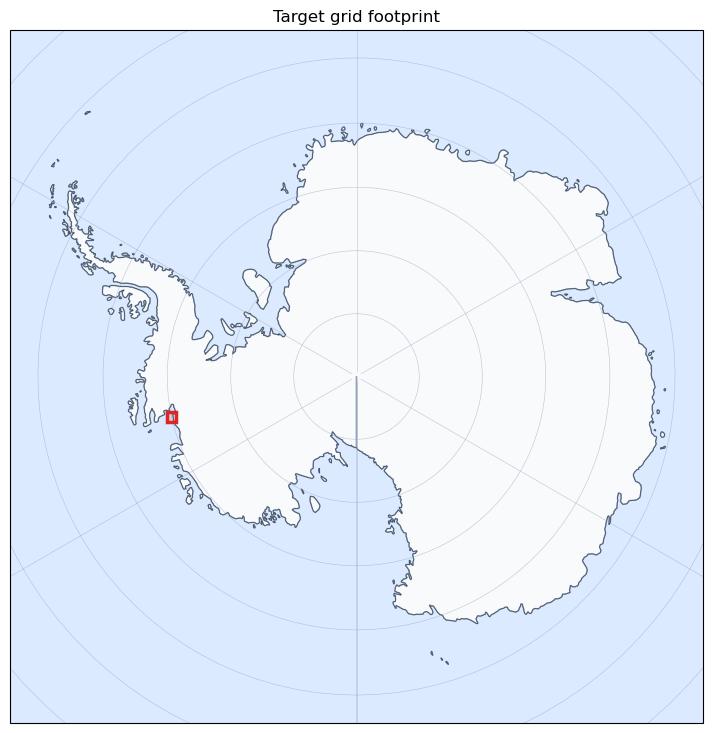

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

antarctic_crs = ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude=-71)

fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=antarctic_crs)
ax.set_xlim(-3_000_000, 3_000_000)
ax.set_ylim(-3_000_000, 3_000_000)
ax.add_feature(cfeature.OCEAN, facecolor="#dbeafe", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f8fafc", edgecolor="#94a3b8", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color="#475569", zorder=2)
ax.gridlines(draw_labels=False, linewidth=0.4, color="#94a3b8", alpha=0.6)

ax.add_patch(
    Rectangle(
        (left, bottom),
        right - left,
        top - bottom,
        facecolor="#dc262620",
        edgecolor="#dc2626",
        linewidth=2.5,
        transform=antarctic_crs,
        zorder=5,
    )
)
ax.set_title("Target grid footprint")
plt.show()


## 2. Interpolation and transormation

In [7]:
def open_remote_zarr(url):
    """Open a remote Zarr store lazily with xarray."""
    return xr.open_zarr(url, chunks={}, consolidated=None)


def interpolate_to_grid(obj, method="nearest"):
    """Interpolate an xarray object with x/y coordinates onto the target grid."""
    source = obj.sortby("x").sortby("y")
    out = source.interp(x=TARGET_TEMPLATE["x"], y=TARGET_TEMPLATE["y"], method=method)
    out = out.assign_coords(x=TARGET_TEMPLATE["x"], y=TARGET_TEMPLATE["y"])
    out.attrs.update(obj.attrs)
    out.attrs["interpolation_method"] = method
    return out


def curvilinear_nearest_to_grid(values, longitude, latitude, name):
    """Project curvilinear lon/lat cells and copy each target cell's nearest value."""
    lon = ((np.asarray(longitude) + 180) % 360) - 180
    lat = np.asarray(latitude)
    source_x, source_y = Transformer.from_crs("EPSG:4326", TARGET_CRS, always_xy=True).transform(lon, lat)

    valid = np.isfinite(source_x) & np.isfinite(source_y) & np.isfinite(lon) & np.isfinite(lat)
    source_points = np.column_stack([source_x[valid], source_y[valid]])

    target_xx, target_yy = np.meshgrid(TARGET_X, TARGET_Y)
    target_points = np.column_stack([target_xx.ravel(), target_yy.ravel()])
    nearest = cKDTree(source_points).query(target_points, k=1)[1]

    data = np.asarray(values)[valid][nearest].reshape(TARGET_SHAPE).astype("float32")
    da = xr.DataArray(data, dims=("y", "x"), coords=TARGET_COORDS, name=name)
    da.attrs.update({"grid_mapping": "spatial_ref", "interpolation_method": "nearest"})
    return da


def clip_to_aoi(gdf):
    """Clip a GeoDataFrame to the target grid footprint."""
    if gdf.crs is None:
        gdf = gdf.set_crs(TARGET_CRS)
    gdf = gdf.to_crs(TARGET_CRS)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

    aoi = box(*TARGET_BOUNDS)
    clipped = gdf.loc[gdf.intersects(aoi)].copy()
    clipped[clipped.geometry.name] = clipped.geometry.intersection(aoi)
    return clipped[~clipped.geometry.is_empty].reset_index(drop=True)


def rasterize_mask(gdf, name, dtype="uint8"):
    """Rasterize AOI features into a binary mask on the target grid."""
    shapes = [(geom, 1) for geom in gdf.geometry if geom is not None and not geom.is_empty]
    data = np.zeros(TARGET_SHAPE, dtype=dtype)
    if shapes:
        data = features.rasterize(
            shapes,
            out_shape=TARGET_SHAPE,
            transform=TARGET_TRANSFORM,
            fill=0,
            dtype=dtype,
            all_touched=True,
        )

    return xr.DataArray(
        data,
        dims=("y", "x"),
        coords=TARGET_COORDS,
        name=name,
        attrs={"grid_mapping": "spatial_ref", "source_type": "geoparquet", "rasterized": "true"},
    )


def cog_to_grid(path, name, method="nearest"):
    """Read the COG window that overlaps the AOI and reproject it to the target grid."""
    with rasterio.open(path) as src:
        src_bounds = transform_bounds(TARGET_CRS, src.crs, *TARGET_BOUNDS, densify_pts=21)
        window = rasterio.windows.from_bounds(*src_bounds, transform=src.transform).round_offsets().round_lengths()
        source = src.read(1, window=window, boundless=True, masked=True).filled(np.nan).astype("float32")

        data = np.full(TARGET_SHAPE, np.nan, dtype="float32")
        reproject(
            source=source,
            destination=data,
            src_transform=src.window_transform(window),
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=TARGET_TRANSFORM,
            dst_crs=TARGET_CRS,
            dst_nodata=np.nan,
            resampling=Resampling[method],
        )

    da = xr.DataArray(data, dims=("y", "x"), coords=TARGET_COORDS, name=name)
    da.attrs.update({"grid_mapping": "spatial_ref", "source_type": "cog", "interpolation_method": method})
    return da


## BedMachine layer

BedMachine is already on a projected `x, y` grid. Clip a slightly larger window, interpolate to the demo grid, and rename the variables for the final cube.

In [8]:
bedmachine = open_remote_zarr(SOURCES["bedmachine_zarr"]).set_index({"x": "x", "y": "y"})

bedmachine_roi = (
    bedmachine[["bed", "thickness", "mask"]]
    .sortby("x")
    .sortby("y")
    .sel(x=slice(left - 2_000, right + 2_000), y=slice(bottom - 2_000, top + 2_000))
)

bed_layer = interpolate_to_grid(bedmachine_roi, method="nearest")
bed_layer = bed_layer.rename(
    {
        "bed": "bedrock_elevation",
        "thickness": "ice_thickness",
        "mask": "bedmachine_mask",
    }
)

bed_layer["bedmachine_mask"] = bed_layer["bedmachine_mask"].round().fillna(0).astype("uint8")
bed_layer["bedrock_elevation"] = bed_layer["bedrock_elevation"].astype("float32")
bed_layer["ice_thickness"] = bed_layer["ice_thickness"].astype("float32")
bed_layer.attrs.update(source_type="zarr", interpolation_method="nearest")

bed_layer


<xarray.Dataset> Size: 1MB
Dimensions:            (y: 400, x: 400)
Coordinates:
  * x                  (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06
  * y                  (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.899e+05
Data variables:
    bedrock_elevation  (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_thickness      (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    bedmachine_mask    (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015
    interpolation_method:        nearest
    source_type:                 zarr

## Basal melt COG layer

The basal-melt map is a raster file, so read the overlapping window and reproject it directly onto the target grid.


In [9]:
basal_melt = cog_to_grid(
    SOURCES["basal_melt_cog"],
    name="ice_shelf_basal_melt_rate",
    method="bilinear",
)

basal_melt


<xarray.DataArray 'ice_shelf_basal_melt_rate' (y: 400, x: 400)> Size: 640kB
array([[0.95849395, 0.94713926, 0.91774195, ...,        nan,        nan,
               nan],
       [0.9641497 , 0.9524861 , 0.92228913, ...,        nan,        nan,
               nan],
       [0.98308116, 0.9703836 , 0.9375097 , ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(400, 400), dtype=float32)
Coordinates:
  * y        (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x        (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Attributes:
    grid_mapping:          spatial_ref
    source_type:           cog
    interpolation_method:  bilinear

## Vector mask layers

GeoParquet vector datasets become binary masks. Each feature is clipped to the AOI, rasterised onto the target grid, and stored as an xarray layer.


In [10]:
vector_sources = {
    "groundlines_parquet": "grounding_line_mask",
    "supraglacial_lakes_parquet": "supraglacial_lake_mask",
    "subglacial_lakes_parquet": "subglacial_lake_mask",
}

vector_layers = []
feature_counts = {}

for source_key, layer_name in vector_sources.items():
    gdf = gpd.read_parquet(SOURCES[source_key], storage_options=S3_OPTIONS)
    clipped = clip_to_aoi(gdf)
    layer = rasterize_mask(clipped, layer_name)
    vector_layers.append(layer)
    feature_counts[layer_name] = len(clipped)

pd.Series(feature_counts, name="features_in_aoi")


grounding_line_mask       9
supraglacial_lake_mask    0
subglacial_lake_mask      0
Name: features_in_aoi, dtype: int64

## Latest calving-front mask

The calving-front file contains multiple times, for the this notebook we only select only the latest timestamp and then rasterise it.


In [11]:
calving_gdf = gpd.read_parquet(SOURCES["calving_fronts_parquet"], storage_options=S3_OPTIONS)
calving_gdf["time"] = pd.to_datetime(calving_gdf["time"])
latest_time = calving_gdf["time"].max()
latest_calving = calving_gdf.loc[calving_gdf["time"] == latest_time]

calving_clipped = clip_to_aoi(latest_calving)
calving_mask = rasterize_mask(calving_clipped, name="calving_front_mask")
calving_mask.attrs["selected_time"] = latest_time.isoformat()

print(f"calving_front_mask: {len(calving_clipped):,} latest features intersect the AOI")
calving_mask


calving_front_mask: 1 latest features intersect the AOI


<xarray.DataArray 'calving_front_mask' (y: 400, x: 400)> Size: 160kB
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], shape=(400, 400), dtype=uint8)
Coordinates:
  * y        (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.897e+05 -3.899e+05
  * x        (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Attributes:
    grid_mapping:   spatial_ref
    source_type:    geoparquet
    rasterized:     true
    selected_time:  2021-03-15T00:00:00

## Surface elevation change layer

SEC is coarser than the target grid. Interpolate the continuous fields with `linear` and the class field with `nearest`.

In [12]:
sec = open_remote_zarr(SOURCES["sec_zarr"])
sec_latest = sec[["sec", "sec_uncertainty", "surface_type"]].isel(time=-1)
sec_latest = sec_latest.set_index({"x": "x", "y": "y"}).drop_vars(["lon", "lat"])

sec_roi = (
    sec_latest
    .sortby("x")
    .sortby("y")
    .sel(x=slice(left - 10_000, right + 10_000), y=slice(bottom - 10_000, top + 10_000))
)

sec_continuous = interpolate_to_grid(sec_roi[["sec", "sec_uncertainty"]], method="linear")
sec_continuous = sec_continuous.rename(
    {
        "sec": "surface_elevation_change_rate",
        "sec_uncertainty": "surface_elevation_change_uncertainty",
    }
)

sec_surface = interpolate_to_grid(sec_roi["surface_type"], method="nearest")
sec_surface = sec_surface.round().fillna(0).astype("uint8").rename("surface_elevation_change_surface_type")

sec_layer = xr.merge([sec_continuous.astype("float32"), sec_surface.to_dataset()])
sec_layer


/tmp/ipykernel_21488/3364620909.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  sec_layer = xr.merge([sec_continuous.astype("float32"), sec_surface.to_dataset()])


<xarray.Dataset> Size: 1MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
    time                                   datetime64[ns] 8B 2020-01-01
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
Data variables:
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    surface_elevation_change_uncertainty   (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    surface_elevation_change_surface_type  (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/41)
    title:                  5yr Antarctic Surface Elevation Change at 5.0km r...
    institution:            University College London (UCL)
    creator_email:          cpom@leeds.ac.uk
    creator_name:           University College London (UCL), Centre for Polar...
    creator_url:            www.cpom.ucl.ac.uk/csopr
    comment:                This data was prepared by UCL as a part of the ES...
    ...                     ...
    dhdt_sw_version:        0ded87aa6
    product_sw_version:     0ded87aa6
    product_created:        2021-06-03T11:07:35Z
    license:                ESA CCI Data Policy: free and open access
    netCDF_version:         NETCDF4
    interpolation_method:   linear

##  Ice velocity layer

Select the velocity data closest to the requested date, interpolate the easting/northing components, and recompute speed on the target grid.


In [13]:
velocity_names = [
    "land_ice_surface_easting_velocity",
    "land_ice_surface_northing_velocity",
]

velocity = open_remote_zarr(SOURCES["ice_velocity_zarr"])
velocity = velocity.set_index({"x": "x", "y": "y", "time": "time"})
velocity_time_slice = velocity[velocity_names].sel(time=VELOCITY_TIME_TARGET, method="nearest")

velocity_roi = (
    velocity_time_slice
    .sortby("x")
    .sortby("y")
    .sel(x=slice(left - 2_000, right + 2_000), y=slice(bottom - 2_000, top + 2_000))
)

velocity_layer = interpolate_to_grid(velocity_roi, method="linear")
velocity_layer = velocity_layer.rename(
    {
        "land_ice_surface_easting_velocity": "ice_velocity_easting",
        "land_ice_surface_northing_velocity": "ice_velocity_northing",
    }
).astype("float32")

velocity_layer["ice_velocity_magnitude"] = np.hypot(
    velocity_layer["ice_velocity_easting"],
    velocity_layer["ice_velocity_northing"],
).astype("float32")

selected_velocity_time = pd.to_datetime(velocity_time_slice["time"].values).strftime("%Y-%m-%d")
velocity_layer.attrs.update(source_type="zarr", interpolation_method="linear", selected_time=selected_velocity_time)
velocity_layer


<xarray.Dataset> Size: 2MB
Dimensions:                 (y: 400, x: 400)
Coordinates:
    crs                     int32 4B ...
    time                    datetime64[ns] 8B 2019-01-01
  * x                       (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06
  * y                       (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.899e+05
Data variables:
    ice_velocity_easting    (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_velocity_northing   (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_velocity_magnitude  (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
Attributes: (12/40)
    title:                     Ice Velocity of the Antarctic Ice Sheet
    institution:               ENVEO IT GmbH
    source:                    Copernicus Sentinel-1A and Sentinel-1B
    history:                   Initial product version 1.3
    references:                https://climate.esa.int/en/projects/ice-sheets...
    tracking_id:               7820956a-a125-4b94-a05f-f5161435aa24
    ...                        ...
    sensor:                    SAR
    spatial_resolution:        200m
    key_variables:             Ice Velocity
    interpolation_method:      linear
    source_type:               zarr
    selected_time:             2019-01-01

## 11. Ice temperature layer

The temperature dataset is curvilinear: it stores latitude and longitude arrays rather than regular `x, y` coordinates. Project those source points to EPSG:3031, then assign each target cell the nearest source value.

In [14]:
ice_temp = open_remote_zarr(SOURCES["ice_temperature_zarr"])

depth_values = np.asarray(ice_temp["depth"].values)
temperature_depth_index = int(np.nanargmin(np.abs(depth_values - ICE_TEMPERATURE_DEPTH_M)))
temperature_depth_m = float(ice_temp["depth"].isel(depth=temperature_depth_index).values)

temperature_k = curvilinear_nearest_to_grid(
    ice_temp["Tice"].isel(depth=temperature_depth_index).values,
    ice_temp["longitude"].values,
    ice_temp["latitude"].values,
    name="ice_temperature",
)

temperature_k.attrs.update(
    long_name="Ice sheet temperature",
    units=ice_temp["Tice"].attrs.get("units", "K"),
    source_type="curvilinear_zarr",
    selected_depth_m=temperature_depth_m,
)

temperature_layer = temperature_k.to_dataset()
temperature_layer


<xarray.Dataset> Size: 646kB
Dimensions:          (y: 400, x: 400)
Coordinates:
  * y                (y) float64 3kB -3.101e+05 -3.103e+05 ... -3.899e+05
  * x                (x) float64 3kB -1.64e+06 -1.64e+06 ... -1.56e+06 -1.56e+06
Data variables:
    ice_temperature  (y, x) float32 640kB nan nan nan nan ... nan nan nan nan

## 3. Merge and write the cube

All layers now share the same coordinates. Merge them into one dataset, add CRS metadata, and write a local Zarr cube.

In [16]:
cube_parts = [
    bed_layer,
    basal_melt.to_dataset(),
    sec_layer,
    velocity_layer,
    temperature_layer,
    calving_mask.to_dataset(),
    *[layer.to_dataset() for layer in vector_layers],
]

cube = xr.merge(cube_parts, compat="override")
cube["spatial_ref"] = TARGET_TEMPLATE["spatial_ref"]

for name, da in cube.data_vars.items():
    if name != "spatial_ref":
        da.attrs.setdefault("grid_mapping", "spatial_ref")

cube.attrs.update(
    title="Sample datacube",
    crs=TARGET_CRS,
    target_resolution_m=TARGET_RESOLUTION_M,
    aoi_center_x_m=AOI_CENTER_XY_M[0],
    aoi_center_y_m=AOI_CENTER_XY_M[1],
    aoi_width_m=AOI_WIDTH_M,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
chunks = {dim: min(size, 256) for dim, size in cube.sizes.items() if dim in {"y", "x"}}

with ProgressBar():
    cube.chunk(chunks).to_zarr(FINAL_CUBE, mode="w", consolidated=True, zarr_format=2)

cube

[########################################] | 100% Completed | 154.18 s


<xarray.Dataset> Size: 7MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
    time                                   datetime64[ns] 8B 2020-01-01
    crs                                    int32 4B ...
Data variables: (12/16)
    bedrock_elevation                      (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_thickness                          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    bedmachine_mask                        (y, x) uint8 160kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ice_shelf_basal_melt_rate              (y, x) float32 640kB 0.9585 ... nan
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    surface_elevation_change_uncertainty   (y, x) float32 640kB dask.array<chunksize=(400, 400), meta=np.ndarray>
    ...                                     ...
    ice_temperature                        (y, x) float32 640kB nan nan ... nan
    calving_front_mask                     (y, x) uint8 160kB 1 1 1 1 ... 1 1 1
    grounding_line_mask                    (y, x) uint8 160kB 0 0 0 0 ... 0 0 0
    supraglacial_lake_mask                 (y, x) uint8 160kB 0 0 0 0 ... 0 0 0
    subglacial_lake_mask                   (y, x) uint8 160kB 0 0 0 0 ... 0 0 0
    spatial_ref                            int64 8B 0
Attributes: (12/31)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       Sample datacube
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    source_type:                 zarr
    crs:                         EPSG:3031
    target_resolution_m:         200
    aoi_center_x_m:              -1600000.0
    aoi_center_y_m:              -350000.0
    aoi_width_m:                 80000

In [ ]:
# Open the written Zarr store to check the final variables and metadata.
demo_cube = xr.open_zarr(FINAL_CUBE, consolidated=True)
demo_cube


<xarray.Dataset> Size: 7MB
Dimensions:                                (y: 400, x: 400)
Coordinates:
    crs                                    int32 4B ...
    time                                   datetime64[ns] 8B ...
  * x                                      (x) float64 3kB -1.64e+06 ... -1.5...
  * y                                      (y) float64 3kB -3.101e+05 ... -3....
Data variables: (12/16)
    bedmachine_mask                        (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    bedrock_elevation                      (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    calving_front_mask                     (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    grounding_line_mask                    (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ice_shelf_basal_melt_rate              (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ice_temperature                        (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    ...                                     ...
    spatial_ref                            int64 8B ...
    subglacial_lake_mask                   (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    supraglacial_lake_mask                 (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_rate          (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_surface_type  (y, x) uint8 160kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    surface_elevation_change_uncertainty   (y, x) float32 640kB dask.array<chunksize=(256, 256), meta=np.ndarray>
Attributes: (12/31)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       Sample datacube
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    source_type:                 zarr
    crs:                         EPSG:3031
    target_resolution_m:         200
    aoi_center_x_m:              -1600000.0
    aoi_center_y_m:              -350000.0
    aoi_width_m:                 80000

/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pangeo/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/krasen/micromamba/envs/pan

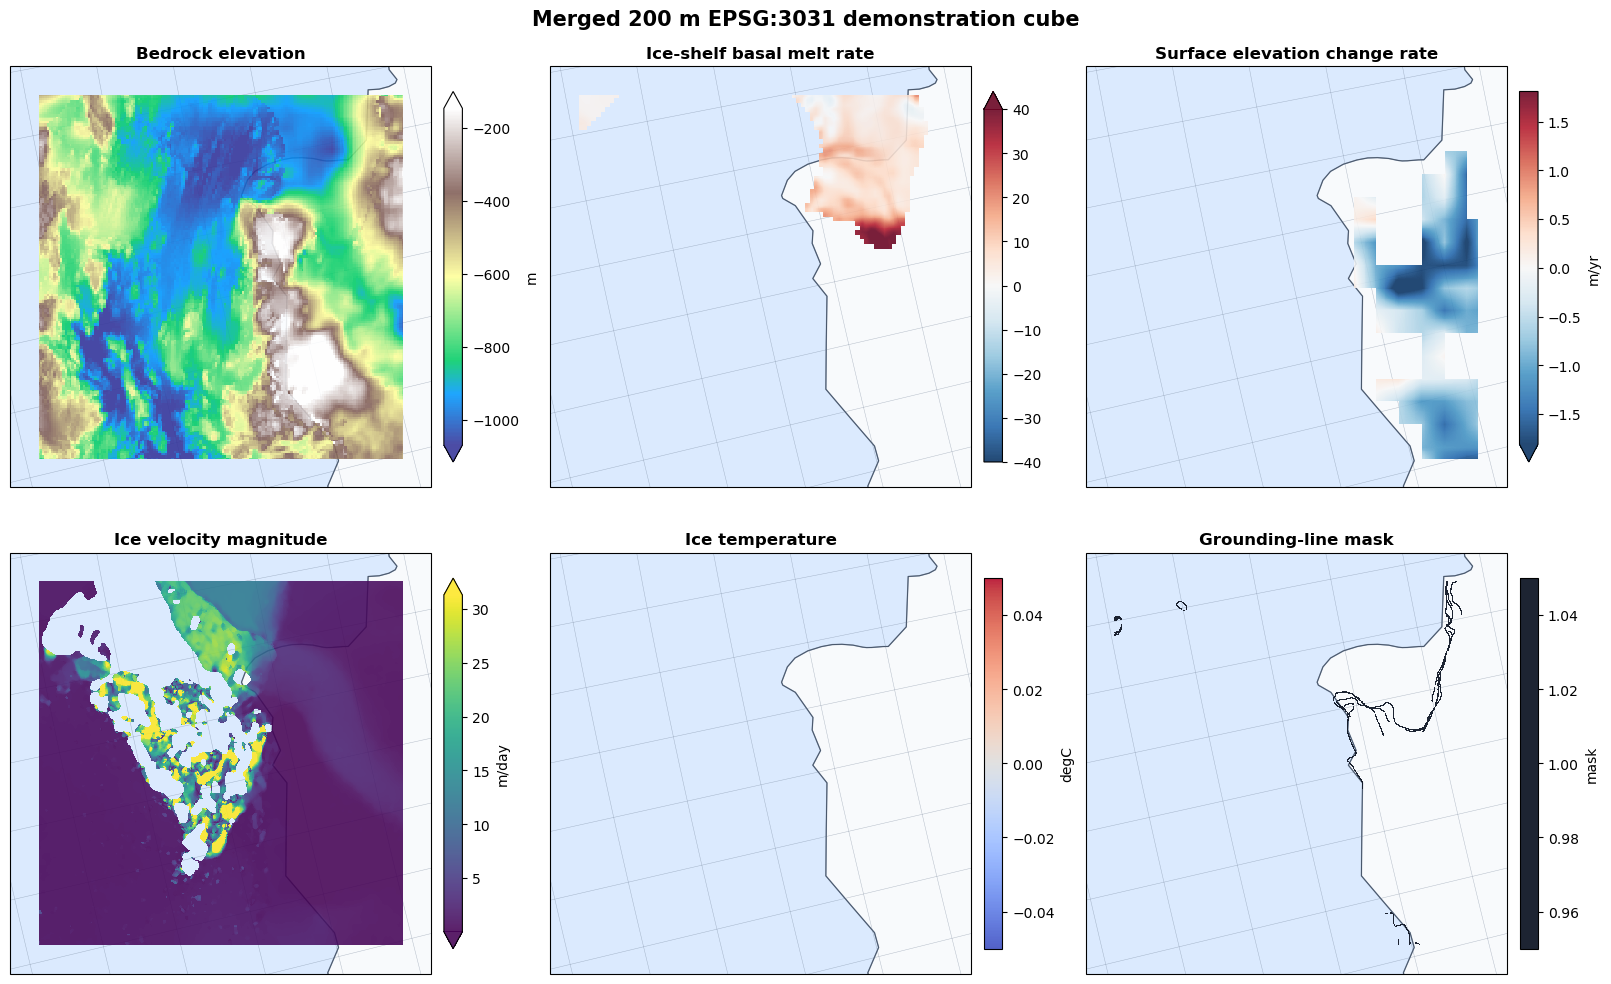

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

antarctic_crs = ccrs.SouthPolarStereo(central_longitude=0, true_scale_latitude=-71)

plot_specs = {
    "bedrock_elevation": {"title": "Bedrock elevation", "cmap": "terrain", "label": "m", "robust": True},
    "ice_shelf_basal_melt_rate": {"title": "Ice-shelf basal melt rate", "cmap": "RdBu_r", "label": demo_cube["ice_shelf_basal_melt_rate"].attrs.get("units", ""), "robust": True},
    "surface_elevation_change_rate": {"title": "Surface elevation change rate", "cmap": "RdBu_r", "label": demo_cube["surface_elevation_change_rate"].attrs.get("units", ""), "robust": True},
    "ice_velocity_magnitude": {"title": "Ice velocity magnitude", "cmap": "viridis", "label": demo_cube["ice_velocity_magnitude"].attrs.get("units", ""), "robust": True},
    "ice_temperature": {"title": "Ice temperature", "cmap": "coolwarm", "label": "degC", "robust": True},
    "grounding_line_mask": {"title": "Grounding-line mask", "cmap": ListedColormap(["#111827"]), "label": "mask", "robust": False},
}

plot_vars = list(plot_specs)
left_plot = float(demo_cube.x.min())
right_plot = float(demo_cube.x.max())
bottom_plot = float(demo_cube.y.min())
top_plot = float(demo_cube.y.max())
pad_x = (right_plot - left_plot) * 0.08
pad_y = (top_plot - bottom_plot) * 0.08

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10),
    subplot_kw={"projection": antarctic_crs},
    constrained_layout=True,
)

for ax, name in zip(axes.ravel(), plot_vars):
    spec = plot_specs[name]
    da = demo_cube[name]

    if name == "ice_temperature":
        da = da - 273.15
        da.attrs["units"] = "degC"

    if name.endswith("_mask"):
        da = da.where(da > 0)

    ax.set_xlim(left_plot - pad_x, right_plot + pad_x)
    ax.set_ylim(bottom_plot - pad_y, top_plot + pad_y)
    ax.add_feature(cfeature.OCEAN, facecolor="#dbeafe", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f8fafc", edgecolor="#94a3b8", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, color="#475569", zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.35, color="#64748b", alpha=0.45, zorder=3)

    da.plot(
        ax=ax,
        transform=antarctic_crs,
        cmap=spec["cmap"],
        robust=spec["robust"],
        add_colorbar=True,
        cbar_kwargs={"label": spec["label"], "shrink": 0.78, "pad": 0.03},
        alpha=0.88 if not name.endswith("_mask") else 0.95,
        zorder=4,
    )

    ax.set_title(spec["title"], fontsize=12, weight="semibold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect("equal")

fig.suptitle("Merged 200 m EPSG:3031 demonstration cube", fontsize=15, weight="bold")
plt.show()
